## Diffusion Models con Classifier-Free Guidance (CFG)

**Author:** alberto.suarez@uam.es  
**Modificado para CFG:** generación condicionada de dígitos SVHN  
**Date:** 2025-03-02


---
## Fundamento Matemático: Classifier-Free Guidance

### Objetivo

Queremos generar muestras condicionadas a una clase $c$ (p. ej., el dígito "3") usando un único modelo de score, sin necesidad de entrenar un clasificador auxiliar.

---

### 1. El score condicional como suma de scores

La función de score condicional se define como el gradiente del log-posterior:

$$
\nabla_{\mathbf{x}} \log p(\mathbf{x} \mid c)
= \nabla_{\mathbf{x}} \log p(\mathbf{x}) + \nabla_{\mathbf{x}} \log p(c \mid \mathbf{x})
$$

El segundo término, $\nabla_{\mathbf{x}} \log p(c \mid \mathbf{x})$, es el **gradiente de un clasificador**. La idea de *classifier guidance* (Dhariwal & Nichol, 2021) era entrenar ese clasificador explícitamente. CFG elimina esa necesidad.

---

### 2. El score guiado por CFG

CFG (Ho & Salimans, 2022) reescribe el score condicional **escalando** el término clasificador con un parámetro de guía $w \geq 0$:

$$
\tilde{s}_\theta(\mathbf{x}, t, c)
= \underbrace{s_\theta(\mathbf{x}, t, \varnothing)}_{\text{score no condicional}}
+ w \underbrace{\bigl[s_\theta(\mathbf{x}, t, c) - s_\theta(\mathbf{x}, t, \varnothing)\bigr]}_{\approx\, \nabla \log p(c\mid \mathbf{x})}
$$

que equivale a:

$$
\boxed{\tilde{s}_\theta(\mathbf{x}, t, c)
= (1 + w)\, s_\theta(\mathbf{x}, t, c)
  - w\, s_\theta(\mathbf{x}, t, \varnothing)}
$$

| $w$ | Comportamiento |
|-----|----------------|
| $w = 0$ | Generación no condicionada, $p(\mathbf{x})$ |
| $w = 1$ | Score condicional estándar, $p(\mathbf{x}\mid c)$ |
| $w > 1$ | Guía amplificada: mayor fidelidad a $c$, menor diversidad |

---

### 3. Por qué se necesita el **token nulo** $\varnothing$

La clave de CFG es que el mismo modelo $s_\theta$ debe poder evaluar **dos** scores en inferencia:

1. $s_\theta(\mathbf{x}, t, c)$ — con la etiqueta real de clase.
2. $s_\theta(\mathbf{x}, t, \varnothing)$ — **sin** información de clase.

El **token nulo** $\varnothing$ es un embedding aprendible especial (índice $= n_{\text{clases}}$) que le indica al modelo *"ignora la clase"*. Al sustituirlo, la red produce el score marginal $\nabla \log p(\mathbf{x})$, que actúa como línea de base en la fórmula CFG.

**Sin el token nulo**, no existiría ningún mecanismo para que la red produzca un score no condicional: tendría que entrenarse un segundo modelo separado, duplicando el coste.

#### Entrenamiento con *label dropping*

Durante el entrenamiento, en cada mini-batch se reemplaza la etiqueta real por $\varnothing$ con probabilidad $p_{\text{uncond}}$ (típicamente 0.10–0.20):

$$
c_i =
\begin{cases}
\varnothing & \text{con probabilidad } p_{\text{uncond}} \\
y_i & \text{en caso contrario}
\end{cases}
$$

Esto obliga al modelo a aprender simultáneamente $p(\mathbf{x}\mid c)$ y $p(\mathbf{x})$, sin necesidad de dos redes distintas.

---

### 4. Integración en la SDE inversa

El score guiado $\tilde{s}_\theta$ se usa directamente como estimador del score en el integrador de Euler–Maruyama de la SDE inversa:

$$
d\mathbf{x} = \left[-g(t)^2 \, \tilde{s}_\theta(\mathbf{x}, t, c)\right] dt
+ g(t)\, d\bar{W}
$$

donde $g(t)$ es el coeficiente de difusión del proceso hacia delante.

---


In [14]:
import sys
from pathlib import Path

directorio_padre = str(Path.cwd().parent)

if directorio_padre not in sys.path:
    sys.path.append(directorio_padre)

In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

from diffusion_lib.legacy import diffusion_process as dfp

from diffusion_lib.utils.visualization import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)

n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

device = 'cuda'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of threads: 10


### Dataset — todos los dígitos con etiquetas

A diferencia del notebook original (que filtraba solo el dígito 6),
ahora cargamos **todos los dígitos** del conjunto SVHN junto con sus etiquetas
$y \in \{0, 1, \ldots, 9\}$, que serán la condición $c$ en CFG.

In [16]:
# 1. Apagamos la comprobación de integridad (el MD5) de PyTorch para SVHN
datasets.SVHN._check_integrity = lambda self: True

# 2. Tu código original EXACTAMENTE igual (con download=False)
data_train = datasets.SVHN(
    root='data',
    split='train',
    download=False,
    transform=ToTensor(),
)

n_classes = 10  # dígitos 0–9
NULL_TOKEN = n_classes

batch_size = 32
data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
)

print(f'Total imágenes de entrenamiento: {len(data_train)}')
print(f'Clases: {n_classes}  |  Token nulo (∅): índice {NULL_TOKEN}')

Total imágenes de entrenamiento: 73257
Clases: 10  |  Token nulo (∅): índice 10


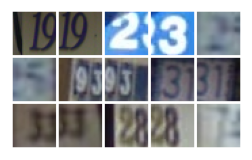

In [17]:
# Visualizar algunas imágenes de entrenamiento
n_rows = 3
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

### Proceso de difusión (sin cambios respecto al original)

In [18]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma=sigma):
    return sigma**t

def bm_mu_t(x_0, t):
    return x_0

def bm_sigma_t(t, sigma=sigma):
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / torch.log(torch.tensor(sigma, device=t.device)))

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=bm_drift_coefficient,
    diffusion_coefficient=bm_diffusion_coefficient,
    mu_t=bm_mu_t,
    sigma_t=bm_sigma_t,
)

### Modelo de score condicional con token nulo

Extendemos `ScoreNet` añadiendo un **embedding de clase** con $n_{\text{clases}} + 1$ entradas:
- Índices $0 \ldots 9$ → embeddings de los dígitos reales.
- Índice $10$ ($= $ `NULL_TOKEN`) → embedding aprendible del token nulo $\varnothing$.

El embedding se suma al embedding temporal antes de pasarlo a la red U-Net,
de modo que la condición $c$ (o su ausencia) fluye por todos los bloques residuales.

In [19]:
from diffusion_lib import UNetScoreModelColor as ScoreNet


class ConditionalScoreNet(nn.Module):
    """
    Envuelve ScoreNet añadiendo un embedding de clase compatible con CFG.

    Parámetros
    ----------
    marginal_prob_std : callable
        Función que devuelve sigma_t dado t (necesaria para ScoreNet).
    n_classes : int
        Número de clases reales (10 para SVHN).
    embed_dim : int
        Dimensión del embedding de clase. Debe coincidir con el embed
        temporal interno de ScoreNet (por defecto 256).
    null_token : int
        Índice reservado para el token nulo ∅  (= n_classes).
    """

    def __init__(
        self,
        marginal_prob_std,
        n_classes: int = 10,
        embed_dim: int = 256,
        null_token: int = None,
    ):
        super().__init__()
        self.null_token = null_token if null_token is not None else n_classes

        # Red base (sin modificar)
        self.score_net = ScoreNet(marginal_prob_std=marginal_prob_std)

        # Embedding de clase: n_classes entradas reales + 1 token nulo
        self.class_embed = nn.Embedding(
            num_embeddings=n_classes + 1,  # +1 para ∅
            embedding_dim=embed_dim,
        )

        # Proyección del embedding de clase al espacio de embedding temporal
        # ScoreNet usa embed_dim = 256 internamente; ajustar si difiere.
        self.class_proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, x, t, labels):
        """
        Parámetros
        ----------
        x      : Tensor [B, C, H, W]  — imagen ruidosa en tiempo t
        t      : Tensor [B]            — tiempos de difusión
        labels : Tensor [B] (int)      — etiquetas de clase o NULL_TOKEN

        Retorna
        -------
        score  : Tensor [B, C, H, W]
        """
        # Embedding de clase (incluye ∅ cuando labels == NULL_TOKEN)
        c_emb = self.class_proj(self.class_embed(labels))  # [B, embed_dim]

        # Pasamos a ScoreNet inyectando el embedding de clase.
        # Si ScoreNet no acepta un argumento extra, lo sumamos antes
        # a la representación temporal usando un hook o subclase.
        # La implementación más limpia (y la que asumimos aquí) es
        # que ScoreNet acepte un argumento `class_emb` opcional.
        # Si no es el caso, ver nota (*) al final de la celda.
        return self.score_net(x, t, class_emb=c_emb)


# (*) Si ScoreNet NO acepta `class_emb`, usa esta alternativa que
#     modifica el embedding temporal via monkey-patch temporal:
#
#   def forward(self, x, t, labels):
#       c_emb = self.class_proj(self.class_embed(labels))
#       # Sumamos directamente a la representación que ScoreNet calcula
#       # internamente en su embed_t. Para ello podemos registrar un
#       # forward hook que añada c_emb al primer tensor de embed.
#       # Ver implementación con hooks a continuación.
#
# ── Versión alternativa con hook ────────────────────────────────────
class ConditionalScoreNetHook(nn.Module):
    """
    Alternativa a ConditionalScoreNet para cuando ScoreNet no soporta
    el argumento `class_emb`. Inyecta el embedding de clase vía
    un forward hook sobre el primer módulo lineal del embed temporal.
    """

    def __init__(self, marginal_prob_std, n_classes=10, embed_dim=256, null_token=None):
        super().__init__()
        self.null_token = null_token if null_token is not None else n_classes
        self.score_net = ScoreNet(marginal_prob_std=marginal_prob_std)
        self.class_embed = nn.Embedding(n_classes + 1, embed_dim)
        self.class_proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.SiLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self._c_emb = None  # almacén temporal para el hook

        # Hook: suma c_emb a la salida del módulo de embed temporal
        # (asumimos que se llama `embed` dentro de ScoreNet)
        def _hook(module, input, output):
            if self._c_emb is not None:
                return output + self._c_emb

        # Registrar en el módulo de embedding temporal de ScoreNet
        # Ajusta 'embed' al nombre real del módulo dentro de ScoreNet
        if hasattr(self.score_net, 'embed'):
            self.score_net.embed.register_forward_hook(_hook)

    def forward(self, x, t, labels):
        self._c_emb = self.class_proj(self.class_embed(labels))
        out = self.score_net(x, t)
        self._c_emb = None
        return out


# ── Instanciación ────────────────────────────────────────────────────
# Usar ConditionalScoreNet si ScoreNet acepta class_emb,
# usar ConditionalScoreNetHook en caso contrario.
score_model = ConditionalScoreNet(
    marginal_prob_std=partial(bm_sigma_t, sigma=sigma),
    n_classes=n_classes,
    embed_dim=256,
    null_token=NULL_TOKEN,
)
score_model = score_model.to(device)
print(f'Parámetros totales: {sum(p.numel() for p in score_model.parameters()):,}')

Parámetros totales: 1,251,552


### Función de pérdida CFG con *label dropping*

La pérdida es la misma de denoising score matching, pero en cada paso
reemplazamos la etiqueta de clase por $\varnothing$ con probabilidad $p_{\text{uncond}}$:

$$
\mathcal{L}(\theta) = \mathbb{E}_{t,\mathbf{x}_0,\boldsymbol{\epsilon}}\left[
  \lambda(t) \left\| s_\theta(\mathbf{x}_t, t, \tilde{c}) + \frac{\boldsymbol{\epsilon}}{\sigma_t} \right\|^2
\right]
$$

donde $\tilde{c} = \varnothing$ con probabilidad $p_{\text{uncond}}$ o $c$ en otro caso.

In [20]:
def cfg_loss_function(
    model,
    x,
    labels,
    diffusion_process,
    null_token: int,
    p_uncond: float = 0.15,
    eps: float = 1e-5,
):
    """
    Pérdida de denoising score matching con label dropping para CFG.

    Parámetros
    ----------
    model            : ConditionalScoreNet
    x                : Tensor [B, C, H, W] — imágenes limpias x_0
    labels           : Tensor [B] (int64)  — etiquetas reales
    diffusion_process: GaussianDiffussionProcess
    null_token       : int — índice del token nulo ∅
    p_uncond         : float — probabilidad de reemplazar c por ∅
    eps              : float — clip inferior de t para estabilidad numérica

    Retorna
    -------
    loss : Tensor escalar
    """
    B = x.shape[0]
    device = x.device

    # ── 1. Muestrear tiempos t ∈ (eps, 1] uniformemente ──────────────
    t = torch.rand(B, device=device) * (1.0 - eps) + eps  # [B]

    # ── 2. Añadir ruido gaussiano según sigma_t ───────────────────────
    sigma_t = diffusion_process.sigma_t(t)              # [B]
    view_shape = [B] + [1] * (x.dim() - 1)             # para broadcasting
    noise = torch.randn_like(x)                         # ε ~ N(0, I)
    x_t = x + sigma_t.view(*view_shape) * noise        # x_t = x_0 + σ_t ε

    # ── 3. Label dropping: sustituir c por ∅ con p_uncond ────────────
    drop_mask = (torch.rand(B, device=device) < p_uncond)  # booleano [B]
    labels_cfg = labels.clone()
    labels_cfg[drop_mask] = null_token                     # ← token nulo ∅

    # ── 4. Evaluar score condicional (o nulo) ─────────────────────────
    score = model(x_t, t, labels_cfg)                   # [B, C, H, W]

    # ── 5. Pérdida: ||score + ε / σ_t||² ponderada por σ_t² ──────────
    # El objetivo de denoising score matching es s ≈ -ε / σ_t
    target = -noise / sigma_t.view(*view_shape)          # [B, C, H, W]
    weight = sigma_t ** 2                                # λ(t) = σ_t²  [B]
    loss_per_sample = weight.view(*view_shape) * (score - target) ** 2
    return loss_per_sample.mean()


print('Función de pérdida CFG definida correctamente.')

Función de pérdida CFG definida correctamente.


In [21]:
# ── Entrenamiento con CFG ─────────────────────────────────────────
# Descomenta para lanzar el entrenamiento desde cero.

from torch.optim import Adam
import tqdm.notebook

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

p_uncond = 0.15   # 15 % de los pasos se entrenan sin etiqueta (token nulo)
n_epochs  = 300
tqdm_epoch = tqdm.notebook.trange(n_epochs)

for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0

    for x, y in data_loader:
        x = x.to(device)                         # [B, 3, 32, 32]
        y = y.to(device).long()                  # [B]  etiquetas 0-9

        loss = cfg_loss_function(
            model=score_model,
            x=x,
            labels=y,
            diffusion_process=diffusion_process,
            null_token=NULL_TOKEN,
            p_uncond=p_uncond,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss  += loss.item() * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description(
        'Loss promedio: {:.5f}'.format(avg_loss / num_items)
    )

# Guardar checkpoint con la clase condicionada
torch.save(score_model.state_dict(), '../other_checkpoints/cfg_score_model_{:d}_epochs.pth'.format(n_epochs))

  0%|          | 0/300 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Muestreo con Classifier-Free Guidance

Durante la generación, sustituimos el score neto del integrador por el **score guiado**:

$$
\tilde{s}_\theta(\mathbf{x}, t, c) = (1 + w)\, s_\theta(\mathbf{x}, t, c) - w\, s_\theta(\mathbf{x}, t, \varnothing)
$$

Basta con hacer **dos forward passes** por paso de integración: uno con la etiqueta
real $c$ y otro con el token nulo $\varnothing$, y combinarlos linealmente.

In [ ]:
import torch
from functools import partial

n_epochs = 300
checkpoint = torch.load(
    '../other_checkpoints/cfg_score_model_{:d}_epochs.pth'.format(n_epochs),
    map_location='cpu',
)
score_model.load_state_dict(checkpoint)
score_model = score_model.cpu()
score_model.eval()
print('Checkpoint cargado correctamente.')

Checkpoint cargado correctamente.


C:\Users\lucan\AppData\Local\Temp\ipykernel_46504\2753942644.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


In [ ]:
def cfg_backward_drift(
    x_t,
    t,
    model,
    diffusion_coefficient,
    target_label: int,
    null_token: int,
    guidance_scale: float = 3.0,
):
    """
    Drift de la SDE inversa con Classifier-Free Guidance.

    drift = -g(t)² · s̃_θ(x_t, t, c)

    donde s̃_θ = (1 + w)·s_θ(x,t,c) - w·s_θ(x,t,∅)

    Parámetros
    ----------
    x_t              : Tensor [B, C, H, W]
    t                : float o Tensor [B]
    model            : ConditionalScoreNet
    diffusion_coefficient : callable t -> g(t)
    target_label     : int — dígito a generar (0–9)
    null_token       : int — índice del token nulo ∅
    guidance_scale   : float — parámetro w (0 = sin guía, >1 = mayor fidelidad)

    Retorna
    -------
    drift : Tensor [B, C, H, W]
    """
    B = x_t.shape[0]
    device = x_t.device

    if not isinstance(t, torch.Tensor):
        t = torch.tensor([t], device=device, dtype=torch.float32)
    if t.dim() == 0 or t.shape[0] != B:
        t = t.expand(B)

    # Etiquetas: real c y nulo ∅
    labels_cond  = torch.full((B,), target_label, dtype=torch.long, device=device)
    labels_uncond = torch.full((B,), null_token,   dtype=torch.long, device=device)

    # Dos forward passes
    score_cond   = model(x_t, t, labels_cond)    # s_θ(x, t, c)
    score_uncond = model(x_t, t, labels_uncond)  # s_θ(x, t, ∅)

    # Score guiado CFG: (1 + w)·s_cond - w·s_uncond
    w = guidance_scale
    score_cfg = (1.0 + w) * score_cond - w * score_uncond

    # Coeficiente de difusión g(t)
    view_shape = [B] + [1] * (x_t.dim() - 1)
    g_t = diffusion_coefficient(t).view(*view_shape)

    return -(g_t ** 2) * score_cfg


print('Función de drift CFG definida.')

Función de drift CFG definida.


In [ ]:
# ── Parámetros de generación ──────────────────────────────────────────
target_digit  = 9      # dígito a generar (0–9) ← cambia este valor
guidance_scale = 3.0   # w: 0 = sin guía, 1 = condicional estándar, >1 = amplificada
n_images      = 5
n_steps       = 500
T             = 1.0

# Ruido inicial x_T ~ N(0, σ_T² I)
t_tensor = torch.tensor([T], device='cpu')
sigma_max = diffusion_process.sigma_t(t_tensor).detach().cpu()
image_T = torch.randn(n_images, 3, 32, 32, device='cpu') * sigma_max.view(1, 1, 1, 1)

# Integración de la SDE inversa con score guiado por CFG
with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0=T,
        t_end=1.0e-3,
        n_steps=n_steps,
        drift_coefficient=partial(
            cfg_backward_drift,
            model=score_model,
            diffusion_coefficient=bm_diffusion_coefficient,
            target_label=target_digit,
            null_token=NULL_TOKEN,
            guidance_scale=guidance_scale,
        ),
        diffusion_coefficient=bm_diffusion_coefficient,
    )

print(f'Imágenes generadas: {synthetic_images_t.shape}  (dígito objetivo: {target_digit})')

Imágenes generadas: torch.Size([5, 3, 32, 32, 501])  (dígito objetivo: 3)


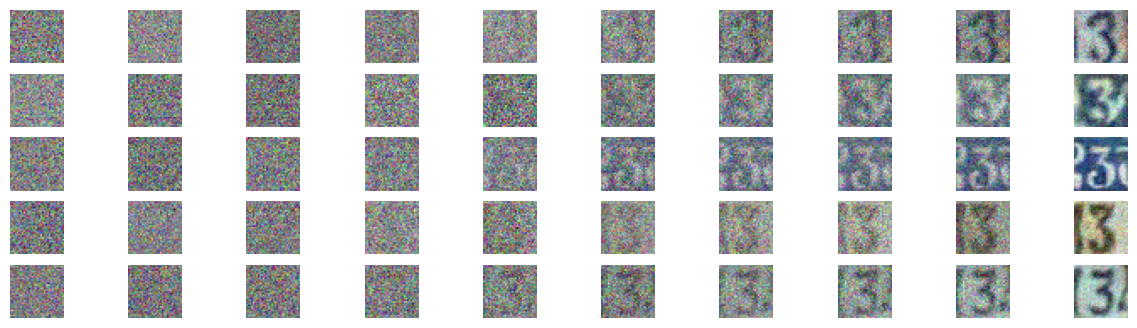

In [ ]:
from diffusion_lib.utils.visualization import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Ablación: efecto del parámetro de guía $w$

Generamos el mismo dígito con distintos valores de `guidance_scale` para
ilustrar el **trade-off fidelidad–diversidad** propio de CFG.

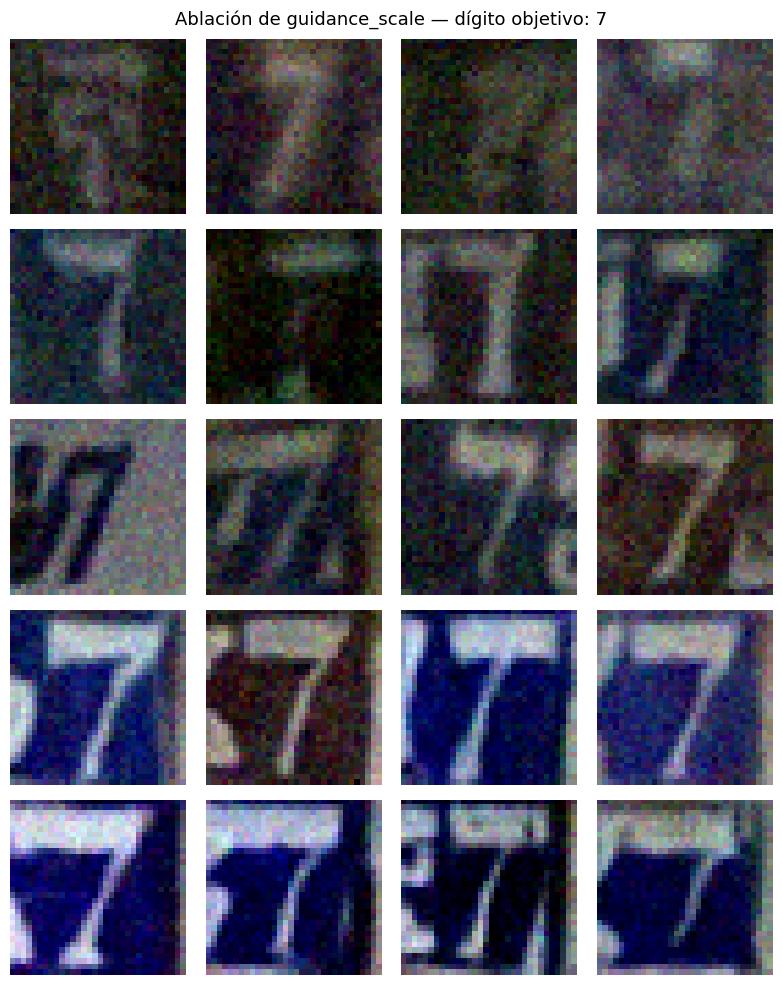

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. PROTECCIÓN CONTRA EL BUG DE MAC (MPS): Movemos el modelo a la CPU
score_model = score_model.to('cpu')

target_digit    = 3          # dígito a explorar
guidance_scales = [0.0, 1.0, 2.0, 5.0, 10.0]
n_imgs_per_w    = 4

fig, axes = plt.subplots(
    len(guidance_scales), n_imgs_per_w,
    figsize=(n_imgs_per_w * 2, len(guidance_scales) * 2),
)

for row, w in enumerate(guidance_scales):
    
    # 2. Generamos el ruido inicial forzándolo a la CPU
    image_T_ab = (torch.randn(n_imgs_per_w, 3, 32, 32) * sigma_max.view(1, 1, 1, 1)).to('cpu')
    
    with torch.no_grad():
        _, imgs_t = dfp.euler_maruyama_integrator(
            image_T_ab,
            t_0=T,
            t_end=1.0e-3,
            n_steps=n_steps,
            drift_coefficient=partial(
                cfg_backward_drift,
                model=score_model,
                diffusion_coefficient=bm_diffusion_coefficient,
                target_label=target_digit,  # Tu número 7 original
                null_token=NULL_TOKEN,
                guidance_scale=w,
            ),
            diffusion_coefficient=bm_diffusion_coefficient,
        )
    
    # 3. EXTRACCIÓN CORRECTA: El tensor es (4, 3, 32, 32, 501). 
    # Con [..., -1] cogemos el último paso de tiempo (501) respetando el resto.
    final_imgs = imgs_t[..., -1]
    
    # Aseguramos límites entre 0 y 1 para matplotlib
    final_imgs = final_imgs.cpu().clamp(0.0, 1.0)  
    
    for col in range(n_imgs_per_w):
        ax = axes[row, col]
        
        # final_imgs[col] es (3, 32, 32). Al permutar queda (32, 32, 3), perfecto para plotear
        ax.imshow(final_imgs[col].permute(1, 2, 0).numpy())
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'w = {w}', fontsize=11, rotation=0, labelpad=50, va='center')

fig.suptitle(f'Ablación de guidance_scale — dígito objetivo: {target_digit}', fontsize=13)
plt.tight_layout()
plt.show()

# Devolvemos el modelo a MPS por si vas a seguir entrenando o usándolo en otras celdas
score_model = score_model.to(device)